# Lab 05: Noise Models and Spatial/Frequency Domain Restoration
This notebook solves all Lab 05 tasks in a question-wise format with clear comments and reproducible results.

## What This Notebook Covers
1. Add six types of noise on a synthetic image and compare quality using PSNR and SSIM.
2. Add periodic noise and remove it using a Butterworth band-reject filter; compare PSNR/SSIM before and after filtering.
3. Add Gaussian noise and apply mean-based restoration filters:
   - Arithmetic mean
   - Geometric mean
   - Harmonic mean
   - Contraharmonic mean
4. Add salt-and-pepper noise and apply order-statistics filters:
   - Median
   - Max
   - Min
   - Midpoint

> All images are processed in grayscale with intensity range [0, 1].

In [1]:
# ================================
# Common imports and helper tools
# ================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import ndimage
from skimage import data, img_as_float
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

np.random.seed(42)

def to_float01(img):
    """Convert image to float in [0, 1]."""
    arr = np.asarray(img, dtype=np.float64)
    if arr.max() > 1.0:
        arr = arr / 255.0
    return np.clip(arr, 0.0, 1.0)

def calc_metrics(reference, test):
    """Return PSNR and SSIM for two [0, 1] grayscale images."""
    ref = to_float01(reference)
    tst = to_float01(test)
    psnr = peak_signal_noise_ratio(ref, tst, data_range=1.0)
    ssim = structural_similarity(ref, tst, data_range=1.0)
    return psnr, ssim

def show_images(images, titles, cols=3, cmap="gray", figsize=(15, 8)):
    """Display a list of images in a grid."""
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for ax, image, title in zip(axes, images, titles):
        ax.imshow(image, cmap=cmap, vmin=0, vmax=1)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    for ax in axes[len(images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def create_synthetic_image(size=256):
    """Create a synthetic grayscale image with gradients and geometric shapes."""
    y, x = np.indices((size, size))
    gradient = (x + y) / (2 * (size - 1))

    circle = ((x - size * 0.30) ** 2 + (y - size * 0.35) ** 2) < (size * 0.13) ** 2
    rectangle = (x > size * 0.58) & (x < size * 0.88) & (y > size * 0.20) & (y < size * 0.45)
    radius2 = (x - size * 0.50) ** 2 + (y - size * 0.75) ** 2
    ring = (radius2 < (size * 0.18) ** 2) & (radius2 > (size * 0.14) ** 2)

    img = 0.15 + 0.70 * gradient
    img[circle] = 0.95
    img[rectangle] = 0.25
    img[ring] = 0.05
    return np.clip(img, 0, 1)

def _standardize_noise(noise):
    noise = noise - np.mean(noise)
    return noise / (np.std(noise) + 1e-12)

def add_noise_from_distribution(img, distribution="gaussian", sigma=0.08):
    """Add different statistical noises with approximately matched variance."""
    image = to_float01(img)
    shape = image.shape

    if distribution == "gaussian":
        raw = np.random.normal(loc=0.0, scale=1.0, size=shape)
    elif distribution == "rayleigh":
        raw = np.random.rayleigh(scale=1.0, size=shape)
    elif distribution == "erlang":
        raw = np.random.gamma(shape=2.0, scale=1.0, size=shape)  # Erlang is a gamma special case
    elif distribution == "exponential":
        raw = np.random.exponential(scale=1.0, size=shape)
    elif distribution == "uniform":
        raw = np.random.uniform(low=-1.0, high=1.0, size=shape)
    elif distribution == "salt_pepper":
        return to_float01(random_noise(image, mode="s&p", amount=0.08))
    else:
        raise ValueError(f"Unsupported distribution: {distribution}")

    noise = sigma * _standardize_noise(raw)
    return np.clip(image + noise, 0.0, 1.0)

def add_periodic_noise(img, amp=0.22, fx=18, fy=18):
    """Add sinusoidal periodic noise with known frequencies."""
    image = to_float01(img)
    m, n = image.shape
    y, x = np.indices((m, n))

    periodic_noise = 0.5 * amp * np.sin(2 * np.pi * fx * x / n) + 0.5 * amp * np.sin(2 * np.pi * fy * y / m)
    noisy = np.clip(image + periodic_noise, 0.0, 1.0)
    return noisy, periodic_noise

def butterworth_band_reject(shape, D0, W, order=2):
    """Create a Butterworth band-reject filter in centered frequency coordinates."""
    p, q = shape
    u = np.arange(p) - p / 2
    v = np.arange(q) - q / 2
    vv, uu = np.meshgrid(v, u)
    D = np.sqrt(uu ** 2 + vv ** 2)

    eps = 1e-8
    denominator = np.abs(D ** 2 - D0 ** 2) + eps
    H = 1.0 / (1.0 + ((D * W) / denominator) ** (2 * order))
    return H

def apply_frequency_filter(img, H):
    """Apply centered frequency-domain filter and return filtered image and spectra."""
    image = to_float01(img)
    F = np.fft.fftshift(np.fft.fft2(image))
    G = F * H
    filtered = np.real(np.fft.ifft2(np.fft.ifftshift(G)))
    return np.clip(filtered, 0.0, 1.0), F, G

def arithmetic_mean_filter(img, k=3):
    return np.clip(ndimage.uniform_filter(img, size=k, mode="reflect"), 0.0, 1.0)

def geometric_mean_filter(img, k=3):
    eps = 1e-8
    log_img = np.log(np.clip(img, eps, 1.0))
    return np.clip(np.exp(ndimage.uniform_filter(log_img, size=k, mode="reflect")), 0.0, 1.0)

def harmonic_mean_filter(img, k=3):
    eps = 1e-8
    inv = 1.0 / np.clip(img, eps, 1.0)
    denom = ndimage.convolve(inv, np.ones((k, k)), mode="reflect")
    return np.clip((k * k) / np.maximum(denom, eps), 0.0, 1.0)

def contraharmonic_mean_filter(img, k=3, Q=1.5):
    eps = 1e-8
    kernel = np.ones((k, k), dtype=np.float64)
    numerator = ndimage.convolve(np.power(img + eps, Q + 1), kernel, mode="reflect")
    denominator = ndimage.convolve(np.power(img + eps, Q), kernel, mode="reflect")
    return np.clip(numerator / np.maximum(denominator, eps), 0.0, 1.0)

def midpoint_filter(img, k=3):
    local_max = ndimage.maximum_filter(img, size=k, mode="reflect")
    local_min = ndimage.minimum_filter(img, size=k, mode="reflect")
    return np.clip((local_max + local_min) / 2.0, 0.0, 1.0)

print("Helper functions loaded successfully.")

Helper functions loaded successfully.


## Question 1: Add Different Noise Models on a Synthetic Image
**Task:** Add the following noises and compare noisy image quality using PSNR and SSIM.

1. Gaussian noise
2. Rayleigh noise
3. Erlang (Gamma) noise
4. Exponential noise
5. Uniform noise
6. Impulse (Salt & Pepper) noise

**Approach:**
- Build a synthetic image (gradient + simple geometric objects).
- Add each noise model with comparable strength.
- Compute PSNR and SSIM with respect to the original synthetic image.

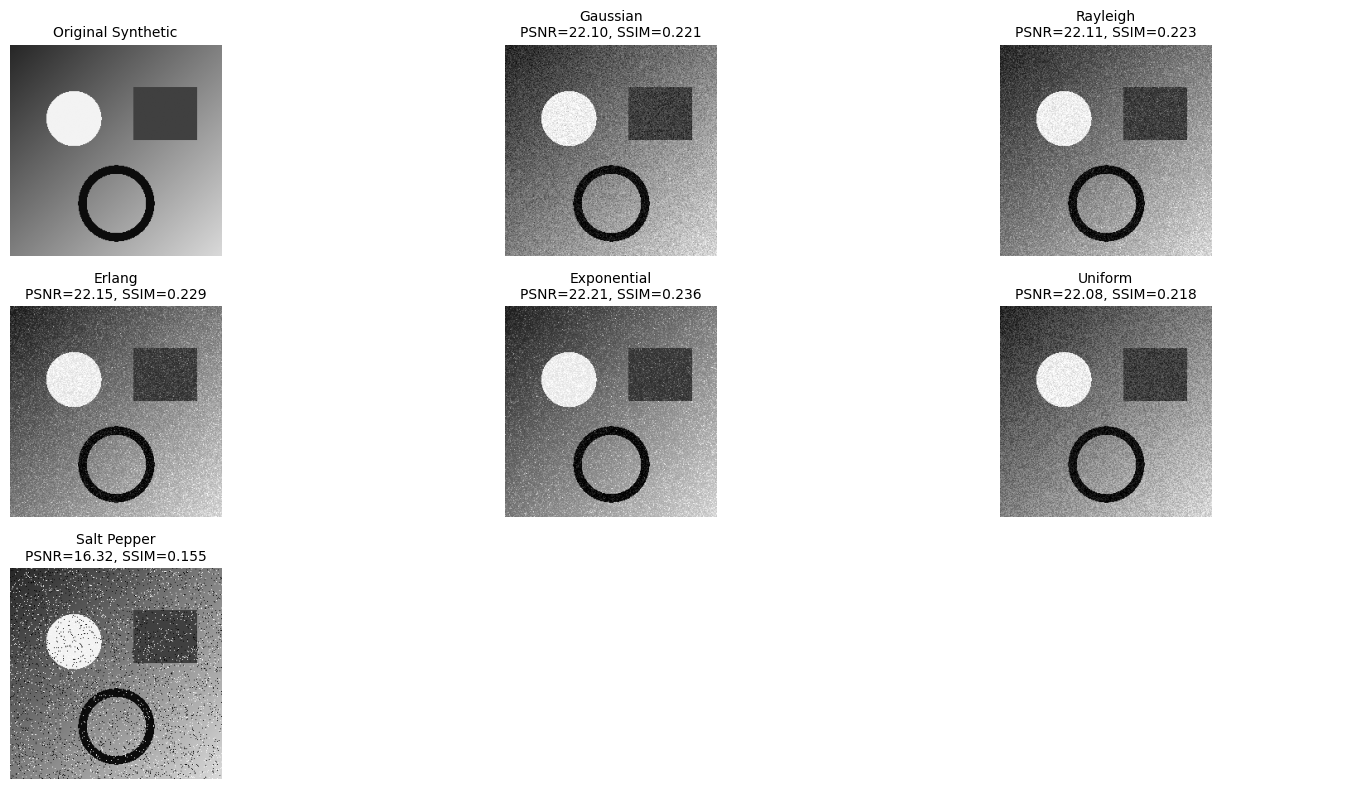

Q1: Noise Quality Comparison


,Noise Type,PSNR (dB),SSIM
0,Exponential,22.215,0.2361
1,Erlang,22.147,0.2286
2,Rayleigh,22.109,0.2226
3,Gaussian,22.096,0.2212
4,Uniform,22.077,0.2181
5,Salt Pepper,16.316,0.1549


In [2]:
# Q1 Solution: Noise addition and quality comparison with PSNR/SSIM
synthetic = create_synthetic_image(size=256)

noise_types = [
    "gaussian",
    "rayleigh",
    "erlang",
    "exponential",
    "uniform",
    "salt_pepper",
]

results_q1 = []
images_q1 = [synthetic]
titles_q1 = ["Original Synthetic"]

for ntype in noise_types:
    noisy = add_noise_from_distribution(synthetic, distribution=ntype, sigma=0.08)
    psnr, ssim = calc_metrics(synthetic, noisy)

    results_q1.append({
        "Noise Type": ntype.replace("_", " ").title(),
        "PSNR (dB)": round(psnr, 3),
        "SSIM": round(ssim, 4),
    })

    images_q1.append(noisy)
    titles_q1.append(f"{ntype.replace('_', ' ').title()}\nPSNR={psnr:.2f}, SSIM={ssim:.3f}")

show_images(images_q1, titles_q1, cols=3, figsize=(15, 8))
df_q1 = pd.DataFrame(results_q1).sort_values(by="PSNR (dB)", ascending=False).reset_index(drop=True)
print("Q1: Noise Quality Comparison")
display(df_q1)

## Question 2: Periodic Noise + Butterworth Band-Reject Filtering
**Task:**
- Add periodic noise to an image.
- Apply a Butterworth band-reject filter in frequency domain.
- Compare quality after noise addition and after filtering using PSNR and SSIM.

**Approach:**
- Use a grayscale test image.
- Inject sinusoidal periodic components with known frequencies.
- Design Butterworth band-reject filter around the periodic frequency radius and restore the image.

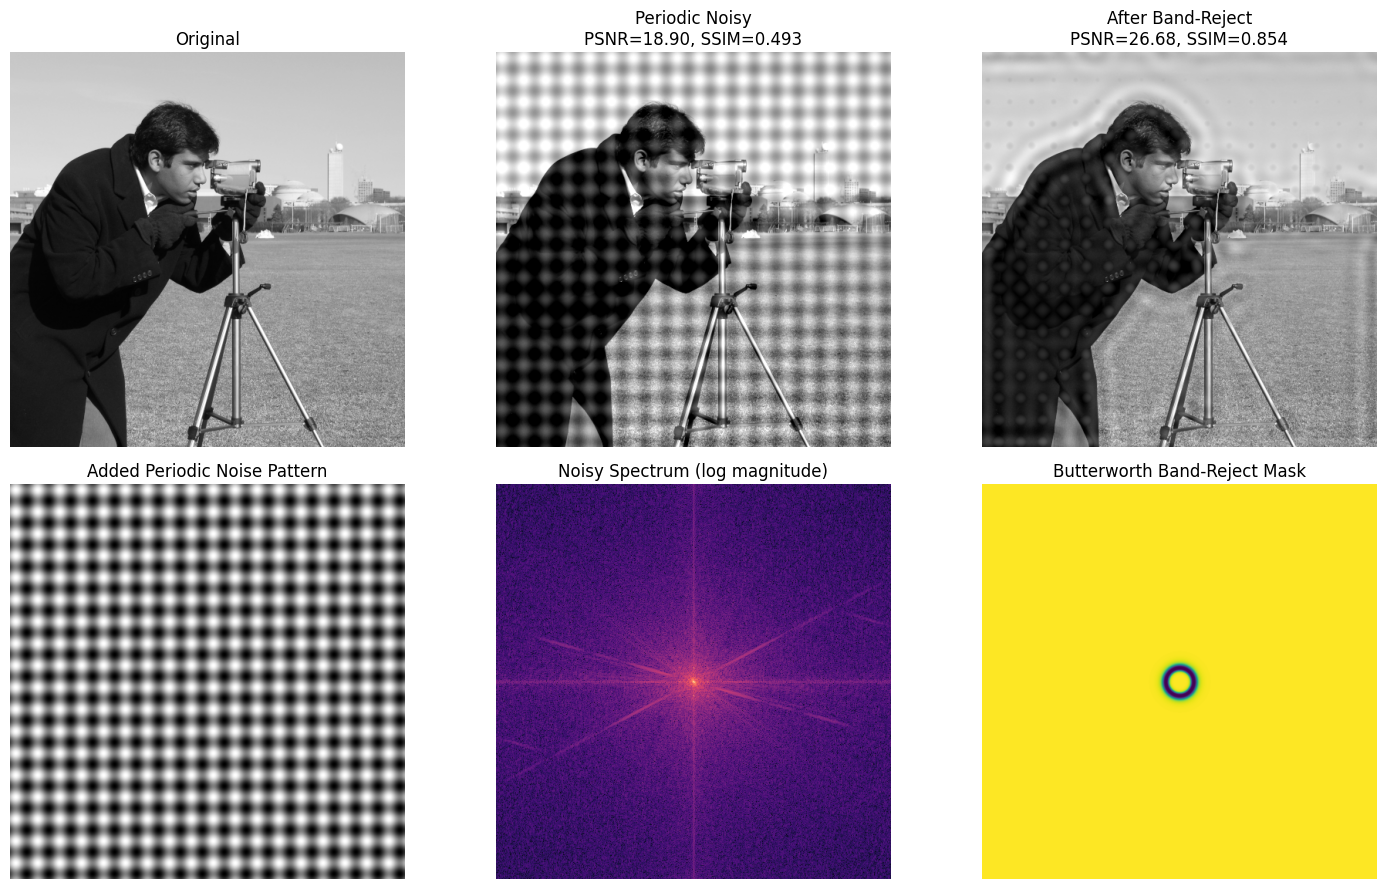

Q2: Quality Comparison


,State,PSNR (dB),SSIM
0,After Noise Addition,18.901,0.4931
1,After Band-Reject Filter,26.678,0.8537


In [3]:
# Q2 Solution: Periodic noise and Butterworth band-reject restoration
img_q2 = to_float01(img_as_float(data.camera()))
noisy_q2, true_periodic_noise = add_periodic_noise(img_q2, amp=0.24, fx=18, fy=18)

# Filter settings: D0 near periodic frequency radius, W controls notch width
D0, W, n_order = 18, 8, 2
H_br = butterworth_band_reject(img_q2.shape, D0=D0, W=W, order=n_order)
restored_q2, F_q2, G_q2 = apply_frequency_filter(noisy_q2, H_br)

psnr_noisy, ssim_noisy = calc_metrics(img_q2, noisy_q2)
psnr_restored, ssim_restored = calc_metrics(img_q2, restored_q2)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes[0, 0].imshow(img_q2, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Original")
axes[0, 1].imshow(noisy_q2, cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title(f"Periodic Noisy\nPSNR={psnr_noisy:.2f}, SSIM={ssim_noisy:.3f}")
axes[0, 2].imshow(restored_q2, cmap="gray", vmin=0, vmax=1)
axes[0, 2].set_title(f"After Band-Reject\nPSNR={psnr_restored:.2f}, SSIM={ssim_restored:.3f}")

axes[1, 0].imshow(true_periodic_noise, cmap="gray")
axes[1, 0].set_title("Added Periodic Noise Pattern")
axes[1, 1].imshow(np.log1p(np.abs(F_q2)), cmap="magma")
axes[1, 1].set_title("Noisy Spectrum (log magnitude)")
axes[1, 2].imshow(H_br, cmap="viridis")
axes[1, 2].set_title("Butterworth Band-Reject Mask")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

df_q2 = pd.DataFrame([
    {"State": "After Noise Addition", "PSNR (dB)": round(psnr_noisy, 3), "SSIM": round(ssim_noisy, 4)},
    {"State": "After Band-Reject Filter", "PSNR (dB)": round(psnr_restored, 3), "SSIM": round(ssim_restored, 4)},
])
print("Q2: Quality Comparison")
display(df_q2)

## Question 3: Gaussian Noise + Mean-Based Filters
**Task:** Take a grayscale image, add Gaussian noise, and implement:
1. Arithmetic mean filter
2. Geometric mean filter
3. Harmonic mean filter
4. Contraharmonic mean filter

**Approach:**
- Add Gaussian noise with controlled variance.
- Apply each filter using a 3x3 neighborhood.
- Compare restored results by PSNR and SSIM against original image.

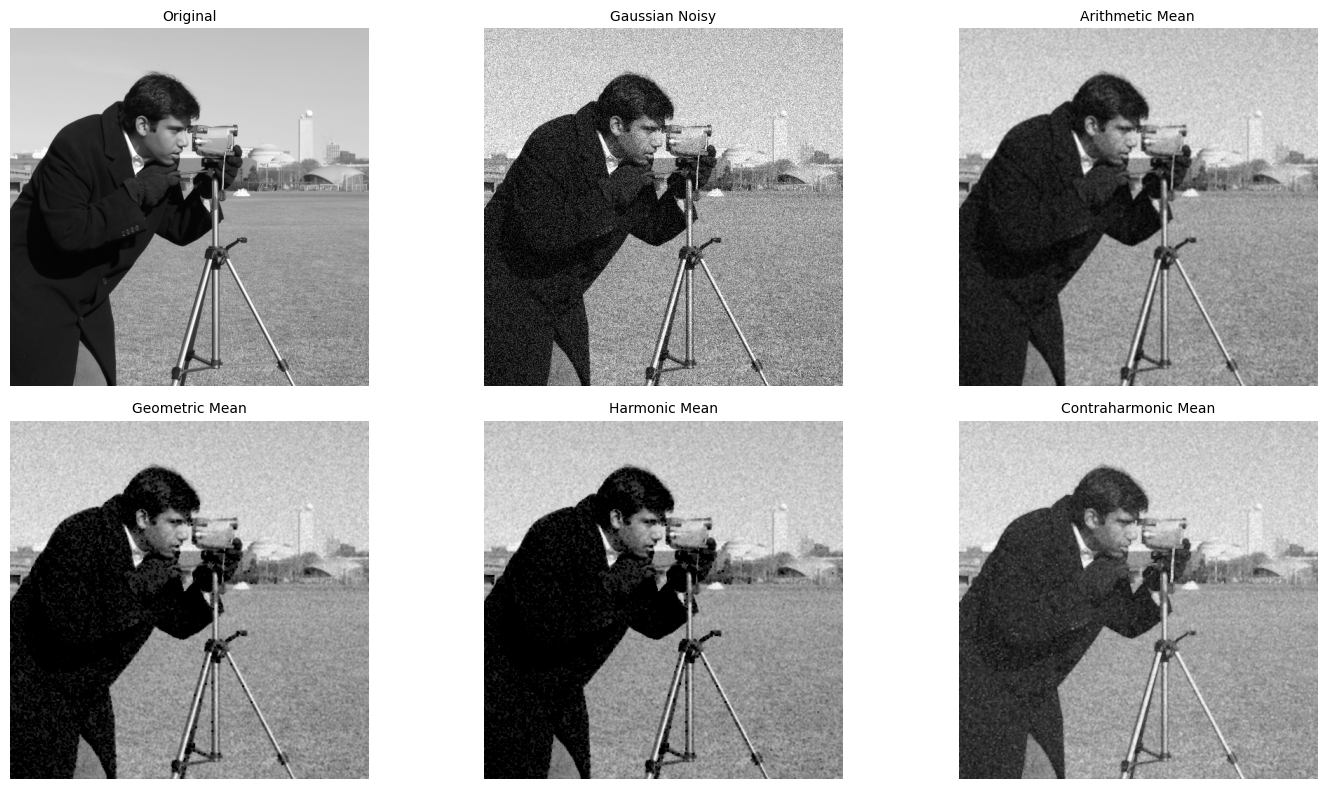

Q3: Filter Performance on Gaussian Noise


,Method,PSNR (dB),SSIM
0,Arithmetic Mean,26.540,0.5730
1,Geometric Mean,23.740,0.4654
2,Harmonic Mean,22.488,0.4326
3,Contraharmonic Mean (Q=1.5),22.043,0.4899
4,Noisy (Gaussian),20.439,0.2963


In [4]:
# Q3 Solution: Mean-based filters for Gaussian noise
img_q3 = to_float01(img_as_float(data.camera()))
gaussian_noisy_q3 = add_noise_from_distribution(img_q3, distribution="gaussian", sigma=0.10)

k_size = 3
arith_q3 = arithmetic_mean_filter(gaussian_noisy_q3, k=k_size)
geom_q3 = geometric_mean_filter(gaussian_noisy_q3, k=k_size)
harm_q3 = harmonic_mean_filter(gaussian_noisy_q3, k=k_size)
contra_q3 = contraharmonic_mean_filter(gaussian_noisy_q3, k=k_size, Q=1.5)

methods_q3 = {
    "Noisy (Gaussian)": gaussian_noisy_q3,
    "Arithmetic Mean": arith_q3,
    "Geometric Mean": geom_q3,
    "Harmonic Mean": harm_q3,
    "Contraharmonic Mean (Q=1.5)": contra_q3,
}

rows_q3 = []
for name, out in methods_q3.items():
    psnr, ssim = calc_metrics(img_q3, out)
    rows_q3.append({"Method": name, "PSNR (dB)": round(psnr, 3), "SSIM": round(ssim, 4)})

show_images(
    [img_q3, gaussian_noisy_q3, arith_q3, geom_q3, harm_q3, contra_q3],
    [
        "Original",
        "Gaussian Noisy",
        "Arithmetic Mean",
        "Geometric Mean",
        "Harmonic Mean",
        "Contraharmonic Mean",
    ],
    cols=3,
    figsize=(15, 8),
)

df_q3 = pd.DataFrame(rows_q3).sort_values(by="PSNR (dB)", ascending=False).reset_index(drop=True)
print("Q3: Filter Performance on Gaussian Noise")
display(df_q3)

## Question 4: Salt-and-Pepper Noise + Order-Statistics Filters
**Task:** Add salt-and-pepper noise and implement:
1. Median filter
2. Max filter
3. Min filter
4. Midpoint filter

**Approach:**
- Corrupt grayscale image using impulse noise.
- Apply each order-statistics filter with 3x3 neighborhood.
- Compare restoration quality using PSNR and SSIM.

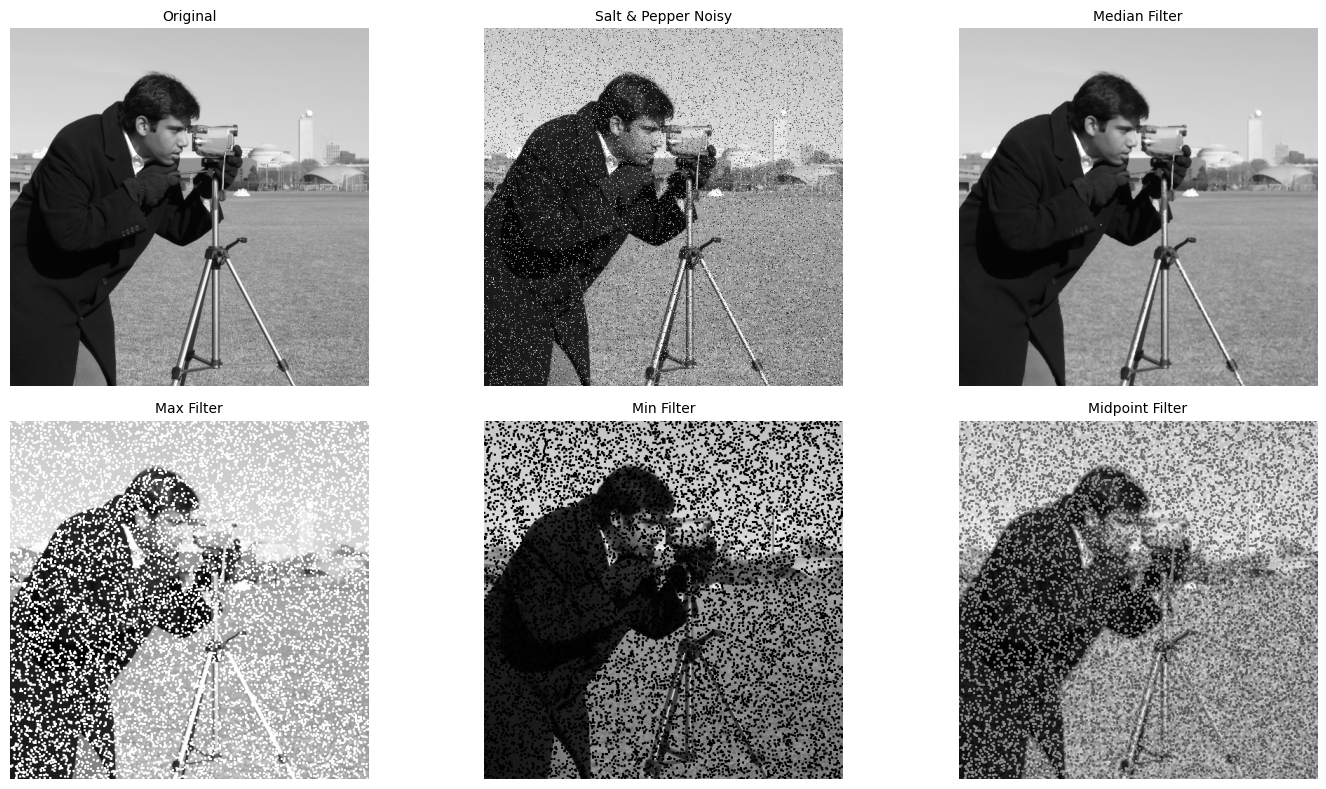

Q4: Filter Performance on Salt-and-Pepper Noise


,Method,PSNR (dB),SSIM
0,Median Filter,29.774,0.8606
1,Noisy (Salt & Pepper),15.680,0.2367
2,Midpoint Filter,13.754,0.1097
3,Max Filter,9.733,0.1283
4,Min Filter,9.589,0.1739


In [5]:
# Q4 Solution: Order-statistics filters for salt-and-pepper noise
img_q4 = to_float01(img_as_float(data.camera()))
sp_noisy_q4 = add_noise_from_distribution(img_q4, distribution="salt_pepper")

k_size = 3
median_q4 = ndimage.median_filter(sp_noisy_q4, size=k_size, mode="reflect")
max_q4 = ndimage.maximum_filter(sp_noisy_q4, size=k_size, mode="reflect")
min_q4 = ndimage.minimum_filter(sp_noisy_q4, size=k_size, mode="reflect")
mid_q4 = midpoint_filter(sp_noisy_q4, k=k_size)

methods_q4 = {
    "Noisy (Salt & Pepper)": sp_noisy_q4,
    "Median Filter": median_q4,
    "Max Filter": max_q4,
    "Min Filter": min_q4,
    "Midpoint Filter": mid_q4,
}

rows_q4 = []
for name, out in methods_q4.items():
    psnr, ssim = calc_metrics(img_q4, out)
    rows_q4.append({"Method": name, "PSNR (dB)": round(psnr, 3), "SSIM": round(ssim, 4)})

show_images(
    [img_q4, sp_noisy_q4, median_q4, max_q4, min_q4, mid_q4],
    [
        "Original",
        "Salt & Pepper Noisy",
        "Median Filter",
        "Max Filter",
        "Min Filter",
        "Midpoint Filter",
    ],
    cols=3,
    figsize=(15, 8),
)

df_q4 = pd.DataFrame(rows_q4).sort_values(by="PSNR (dB)", ascending=False).reset_index(drop=True)
print("Q4: Filter Performance on Salt-and-Pepper Noise")
display(df_q4)